# The 60/40 Portfolio 🏦
### Is the classic balanced fund really the sensible default — and do bonds always cushion the crash?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Bonds cushion every crash?: Not supported](https://img.shields.io/badge/Bonds_cushion_every_crash%3F-Not_supported-8b949e?style=flat-square)

Sixty percent stocks, forty percent bonds: the default an adviser hands you, sold as *most of the stock return with much less risk*. We build the fixed 60/40 (rebalanced once a year) and ask the three questions that matter: is the calmer ride **real** (yes), is it worth running (**yes, with caveats**), and do bonds really **cushion every crash** (**no — ask 2022**).

> 📓 **This is the plain-language layer.** The statistics, the bootstrap and the bond-bull caveat are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (balancing_act/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from balancing_act import data, strategy

AS_OF = "2026-06-12"
prices = data.load_real(("SPY", "IEF", "TLT", "SHY")).loc[:AS_OF]
rets = strategy.to_returns(prices)
rf = rets["SHY"]
blend_ret = strategy.rebalanced_blend(rets, {"SPY": 0.60, "IEF": 0.40}, "annual", cost_bps=2.0)
blend = strategy.stats(blend_ret, rf=rf)
spy = strategy.stats(strategy.single_asset(rets, "SPY"), rf=rf)
print(f"panel: {len(prices):,} rows  {prices.index[0].date()} -> {prices.index[-1].date()}  fingerprint={data.fingerprint(prices)}")
print(f"60/40  Sharpe(xs) {blend['sharpe']:.3f}  vol {blend['vol']*100:.1f}%  maxDD {blend['max_dd']*100:.1f}%  CAGR {blend['cagr']*100:.2f}%")
print(f"SPY    Sharpe(xs) {spy['sharpe']:.3f}  vol {spy['vol']*100:.1f}%  maxDD {spy['max_dd']*100:.1f}%  CAGR {spy['cagr']*100:.2f}%")


panel: 6,006 rows  2002-07-30 -> 2026-06-11  fingerprint=75b675e02dc5
60/40  Sharpe(xs) 0.655  vol 10.2%  maxDD -29.8%  CAGR 8.63%
SPY    Sharpe(xs) 0.541  vol 18.8%  maxDD -55.2%  CAGR 11.20%


## The answer first 🎯

| Question | Answer |
|---|---|
| Is the calmer ride real? | **Yes** — half the volatility (**10.2%** vs **18.8%**) and roughly half the worst drop (**-29.8%** vs **-55.2%**). |
| Does it earn its keep? | **Better risk-adjusted** (Sharpe **0.655** vs **0.541**) — but you give up about **2.6 points/yr** of return. |
| Do bonds cushion *every* crash? | **No** — they helped in **6 of 8** equity crashes, but in **2022** stocks *and* bonds fell together. |

## 1 · The claim

*"The classic 60/40 stock/bond portfolio is the sensible default. You get most of the stock return with much less risk, a better risk-adjusted outcome than 100% stocks, and bonds cushion every equity crash."* It's the balanced-fund tradition — Vanguard's balanced index fund, the Wellington Fund — the thing most people are quietly invested in.

## 2 · So what?

If 60/40 really is a free improvement — same-ish return, much less risk — then it's the right default for almost everyone, and the 2022 *"death of 60/40"* headlines were noise. If the cushion is conditional, the default needs a warning label. Either way it's worth settling on the actual tape rather than on a fund brochure.

## 3 · How would we even know?

We hold 60% SPY and 40% IEF (7-10y Treasuries), both **total return**, and reset to those weights once a year. We compare it to **100% stocks**, measuring risk-adjusted return as **Sharpe above cash** (so the part-bond mix and full stocks race fairly). Then we test the cushion directly: every time stocks fell more than 10%, **did bonds rise?** And we zoom on **2022**, the year everyone says broke the mix.

## 4 · The teardown — let's actually look

First, the two equity curves and their drawdowns.

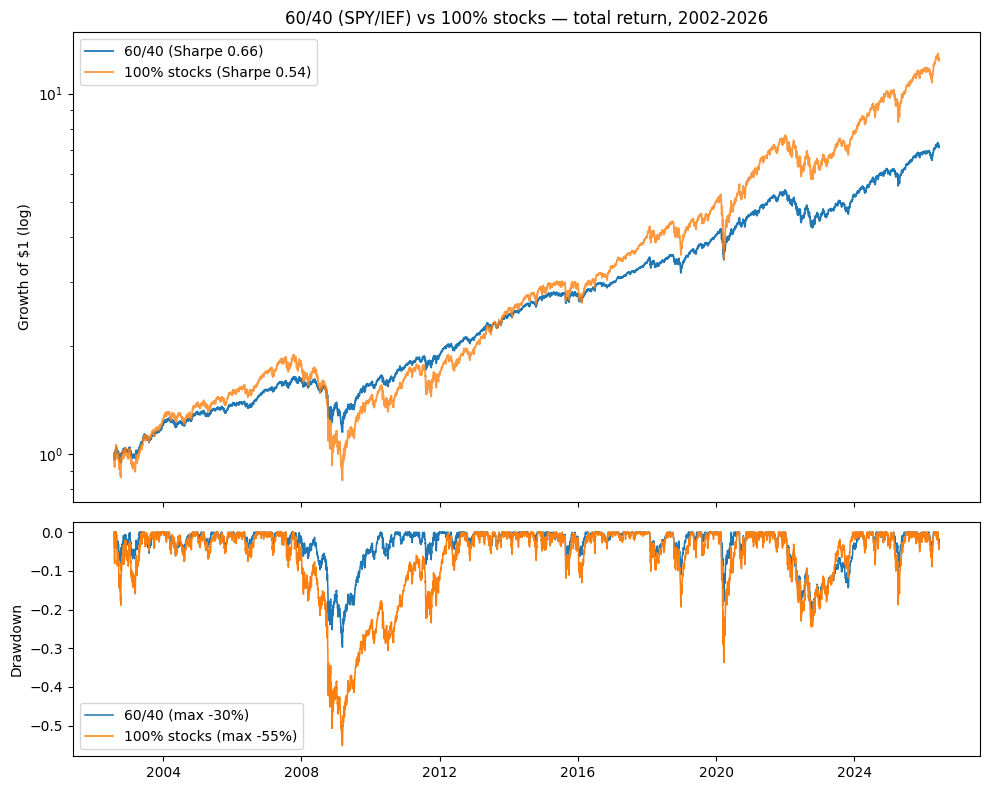

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])
ax1.plot(blend['equity'], label=f"60/40 (Sharpe {blend['sharpe']:.2f})", lw=1.3)
ax1.plot(spy['equity'], label=f"100% stocks (Sharpe {spy['sharpe']:.2f})", lw=1.3, alpha=.8)
ax1.set_yscale('log'); ax1.set_ylabel('Growth of $1 (log)'); ax1.legend()
ax1.set_title('60/40 (SPY/IEF) vs 100% stocks — total return, 2002-2026')
for d, lab in [(blend, '60/40'), (spy, '100% stocks')]:
    eq = d['equity']; dd = eq/eq.cummax()-1
    ax2.plot(dd, label=f"{lab} (max {dd.min()*100:.0f}%)", lw=1.1)
ax2.set_ylabel('Drawdown'); ax2.legend(); ax2.set_xlabel('')
plt.tight_layout(); plt.show()

The 60/40 line is **visibly smoother** — it barely flinches in 2008 and 2020. But notice the **end point**: 100% stocks finishes higher. You bought the calmer ride with return.

Now the cushion claim. Here's the **rolling 3-month correlation** between stocks and bonds — negative means they hedge each other, positive means they fall together.

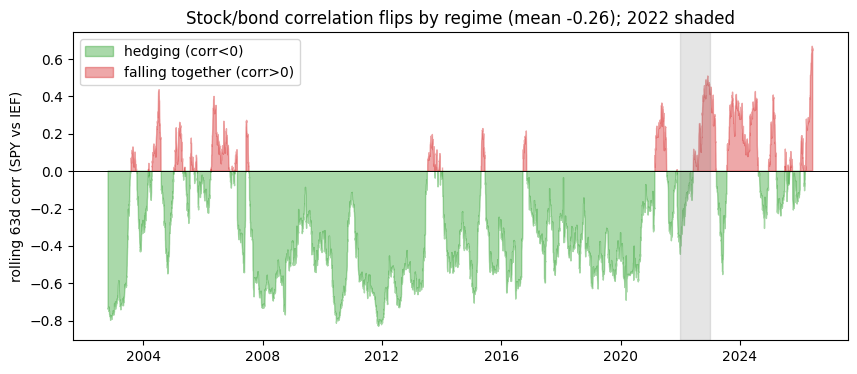

mean -0.26  min -0.83  max +0.67  positive on 23% of days


In [3]:
rc = strategy.rolling_correlation(rets, 'SPY', 'IEF', window=63).dropna()
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(rc.index, rc.values, 0, where=rc.values<0, color='C2', alpha=.4, label='hedging (corr<0)')
ax.fill_between(rc.index, rc.values, 0, where=rc.values>=0, color='C3', alpha=.4, label='falling together (corr>0)')
ax.axhline(0, color='k', lw=.7); ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), color='grey', alpha=.2)
ax.set_ylabel('rolling 63d corr (SPY vs IEF)'); ax.legend(); ax.set_title(f'Stock/bond correlation flips by regime (mean {rc.mean():+.2f}); 2022 shaded')
plt.show()
print(f"mean {rc.mean():+.2f}  min {rc.min():+.2f}  max {rc.max():+.2f}  positive on {(rc>0).mean()*100:.0f}% of days")

On average the correlation is **-0.26** (bonds hedge) — but it swings all the way from **-0.83** to **+0.67**, and is positive **23%** of the time. The cushion is a *tendency*, not a law. And in **2022** (shaded) it went the wrong way.

Finally, the **2022 stress test** — the year of the *"death of 60/40"* headlines:

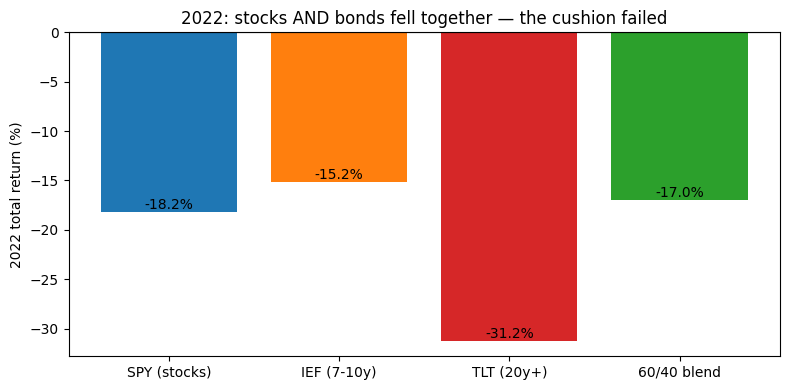

In [4]:
w22 = strategy.window_return(rets[['SPY','IEF','TLT']], '2022-01-01', '2022-12-31')
b22 = strategy.window_return(blend_ret.to_frame('60/40'), '2022-01-01', '2022-12-31')
bars = {'SPY (stocks)': w22['SPY'], 'IEF (7-10y)': w22['IEF'], 'TLT (20y+)': w22['TLT'], '60/40 blend': b22['60/40']}
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(list(bars.keys()), [v*100 for v in bars.values()], color=['C0','C1','C3','C2'])
ax.axhline(0, color='k', lw=.8); ax.set_ylabel('2022 total return (%)')
ax.set_title('2022: stocks AND bonds fell together — the cushion failed')
for i,v in enumerate(bars.values()): ax.text(i, v*100, f'{v*100:+.1f}%', ha='center', va='bottom' if v<0 else 'top')
plt.tight_layout(); plt.show()

In 2022 stocks fell **-18.2%**, but bonds fell *with* them (IEF **-15.2%**, TLT **-31.2%**), so the 60/40 lost **-17.0%** — the cushion became an anchor. That's the one thing the steelman gets wrong.

## 5 · The verdict

- **Signal → Real.** Half the volatility (10.2% vs 18.8%), half the drawdown (-29.8% vs -55.2%), Sharpe 0.655 vs 0.541 — and the edge holds up to honest statistics (next notebook).
- **Tradability → Investable (with caveats).** Two cheap ETFs, rebalanced yearly. But you give up **2.6 pts/yr** of return, and much of the win rode the 40-year **bond bull market** — beta you were paid for, not a free law.
- **Bonds cushion *every* crash? → Not supported.** 6/8 crashes cushioned, but **2022** broke it.

## 6 · Could you actually trade it?

Easily — it's two of the most liquid ETFs on earth and one rebalance a year. As a *default core* it's sensible: real risk reduction at trivial cost. The honest caveats are economic, not frictional — you're accepting **less return for less risk**, and the diversification you're counting on can switch off in an inflation/rate-shock regime, exactly when you'd want it most (2022).

## 7 · Going further 🚪

- Does **TLT** (longer bonds) or a different stock/bond split change the verdict? (We include the TLT variant — try 70/30, 50/50.)
- Add a third diversifier (gold, commodities) — that's the [All-Weather](../../68-all-weather/) study's territory, and it's *volatility*-weighted rather than fixed.
- How much of the Sharpe edge survives if you assume **flat bond yields** going forward? Fork it and strip out the bond bull.